# LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from scipy.stats import randint, uniform
from collections import Counter
from collections import Counter
from imblearn.over_sampling import SMOTE
### Hyperparameter Tuning - XGBoost
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import roc_auc_score
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import randint, uniform
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score



/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [3]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")

X shape : (8381, 17)
y shape : (8381,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1566, 2.0: 936, 3.0: 85}


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100, stratify=y)

In [5]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# XGBoosting

In [12]:
def plot_roc_curve(X_test, y_test, best_model):    
    # Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')

    # ✅ legenda in basso a destra
    plt.legend(loc='lower right')

    plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

"""param_dist = {
    'n_estimators':      randint(200, 800),
    'learning_rate':     uniform(0.01, 0.2),
    'max_depth':         randint(3, 8),
    'min_child_weight':  randint(1, 10),   # ← importante per classi rare
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'gamma':             uniform(0, 2),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(1, 4),
    'max_leaves':        randint(16, 64),
}"""


param_dist = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0.1, 0.01, 0.001],
    'reg_lambda': [0.1, 0.01, 0.001],
    'max_depth': [3, 5, 7],
    'max_leaves': [0, 32, 64],
    'n_jobs': [-1],
    'min_child_weight':  randint(1, 10),   # ← importante per classi rare
    'subsample':         uniform(1, 0.4),
    'colsample_bytree':  uniform(1, 0.4),
}

base_clf = XGBClassifier(
    objective='multi:softprob',   # ← non binary:logistic!
    num_class=4,
    tree_method='hist',           # veloce, supporta GPU
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

rand_search = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_dist,
    cv=cv,
    scoring='f1_macro',           # giusto per classi sbilanciate
    n_iter=80,
    n_jobs=-1,
    refit=True,
    verbose=1,
    random_state=42,
)

In [8]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

rand_search.fit(
    X_train, y_train
    , sample_weight=sample_weights   # ← passati qui
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           im...
                                        'max_leaves': [0, 32, 64],
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ff59e84ce50>,
                                        'n_estimators': [100, 500, 1000],
                                        'n_jobs': [-1],
                                        'reg_alpha': [0.1, 0.01, 0.001],
                                        'reg_lambda': [0.1, 0.01, 0.001],
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ff5a38df790>},
                   random_state=42, scoring='f1_macro', verbose=1)

In [9]:


print("Best params:", rand_search.best_params_)
print("Best CV F1-macro:", rand_search.best_score_)

# Valutazione
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 per classe:", f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Best params: {'colsample_bytree': 0.9618032508488761, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 7, 'max_leaves': 0, 'min_child_weight': 8, 'n_estimators': 500, 'n_jobs': -1, 'reg_alpha': 0.01, 'reg_lambda': 0.001, 'subsample': 0.8489131066246972}
Best CV F1-macro: 0.3286045343053103
Accuracy: 0.5238095238095238
F1 per classe: [0.69502868 0.2562592  0.23376623 0.12      ]
              precision    recall  f1-score   support

         0.0       0.78      0.63      0.70      1161
         1.0       0.24      0.28      0.26       314
         2.0       0.18      0.34      0.23       188
         3.0       0.09      0.18      0.12        17

    accuracy                           0.52      1680
   macro avg       0.32      0.35      0.33      1680
weighted avg       0.61      0.52      0.56      1680



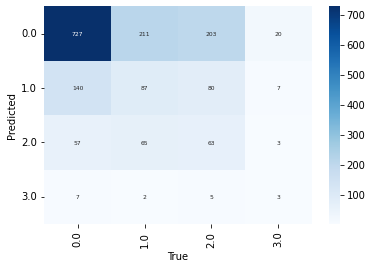

In [10]:
cf = confusion_matrix(y_test, y_pred)

ax= plt.subplot()
sns.heatmap(cf, annot=True, cmap="Blues", fmt='g', annot_kws={"fontsize":6})
ax.xaxis.set_ticklabels(labels=np.sort(np.unique(y)))
ax.yaxis.set_ticklabels(labels=np.sort(np.unique(y)))
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("True")
plt.ylabel("Predicted")

#plt.savefig('./img/Advanced Classification/XGB_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

In [11]:
y_test_pred_proba = best_model.predict_proba(X_test)

auroc = roc_auc_score(
    y_test,
    y_test_pred_proba,
    multi_class='ovr'   # oppure 'ovo'
)

print(auroc)

0.6377484125488662


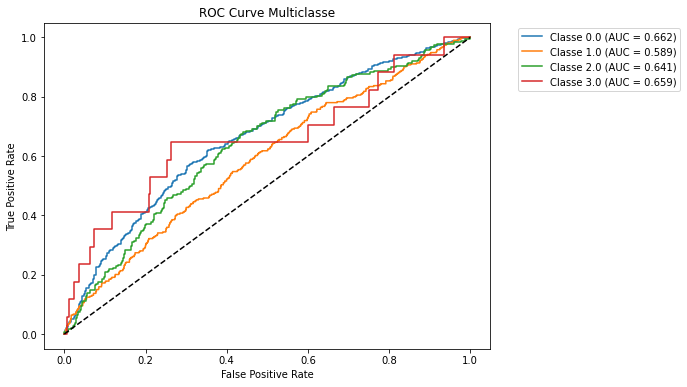

In [12]:
plot_roc_curve(X_test, y_test, best_model)

# feature importance (not to run again randomsearch)

In [7]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("XGBoost Feature Importances")

    plt.show()

In [8]:
base_clf = XGBClassifier(
    objective='multi:softprob',   
    num_class=4,
    tree_method='hist',           
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    colsample_bytree = 0.9618032508488761,
    gamma = 0,
    learning_rate =  0.01,
    max_depth =  7,
    max_leaves = 0,
    min_child_weight = 8,
    n_estimators = 500,
    reg_alpha = 0.01,
    reg_lambda = 0.001,
    subsample = 0.8489131066246972

)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

base_clf.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9618032508488761, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=0,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=4,
              num_parallel_tree=None, ...)

In [9]:
y_pred = base_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 per classe:", f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy: 0.5086463923673226
F1 per classe: [0.68030447 0.21645022 0.23529412 0.12244898]
              precision    recall  f1-score   support

         0.0       0.76      0.62      0.68      1160
         1.0       0.20      0.24      0.22       313
         2.0       0.19      0.32      0.24       187
         3.0       0.09      0.18      0.12        17

    accuracy                           0.51      1677
   macro avg       0.31      0.34      0.31      1677
weighted avg       0.58      0.51      0.54      1677



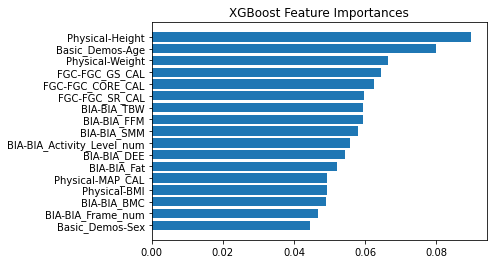

In [10]:
feature_imp(base_clf, attributes)

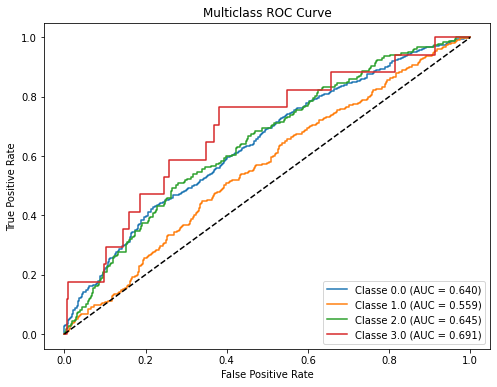

In [13]:
plot_roc_curve(X_test, y_test, base_clf)